In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats

warnings.filterwarnings('ignore')

In [2]:
# loading dataset
conn=sqlite3.connect("inventory.db")
df=pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,107436.0,3881420.64,549794.09,197400.84,68601.68,70169.04,1.807818,0.740529,1.018411
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,124473.0,3767851.23,459750.89,228706.96,144929.24,-36189.99,-0.960494,0.758806,0.990486
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,149367.0,3643388.83,378570.51,274449.16,123780.22,225085.15,6.177906,0.797019,1.065847
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,140201.0,3200219.99,343315.16,257608.11,257032.07,-60977.95,-1.905430,0.695159,0.981302
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,102317.0,3209878.83,443700.00,187995.79,257032.07,186672.82,5.815572,0.740842,1.061747


# Exploratory Data Analysis

* Priviously, we examined the various tables in the databases to identify key variable, understand their relationships, and determine ones should be
included in the final analysis.
* In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each columns. The will help us understand data patterns identify anomaies 
and ensure data quality before proceeding with further analysis

In [3]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,2.360228e+03,8534.209516,0.00,22.000000,177.000000,1422.500000,2.681470e+05
TotalSalesDollars,10692.0,3.213203e+04,128040.730894,0.00,459.770000,3770.265000,21515.750000,3.881421e+06
TotalSalesPrice,10692.0,1.456557e+04,35676.922960,0.00,159.900000,1979.010000,12081.510000,5.497941e+05
TotalExciseTax,10692.0,1.376282e+03,8539.942276,0.00,3.130000,32.715000,306.302500,2.744492e+05


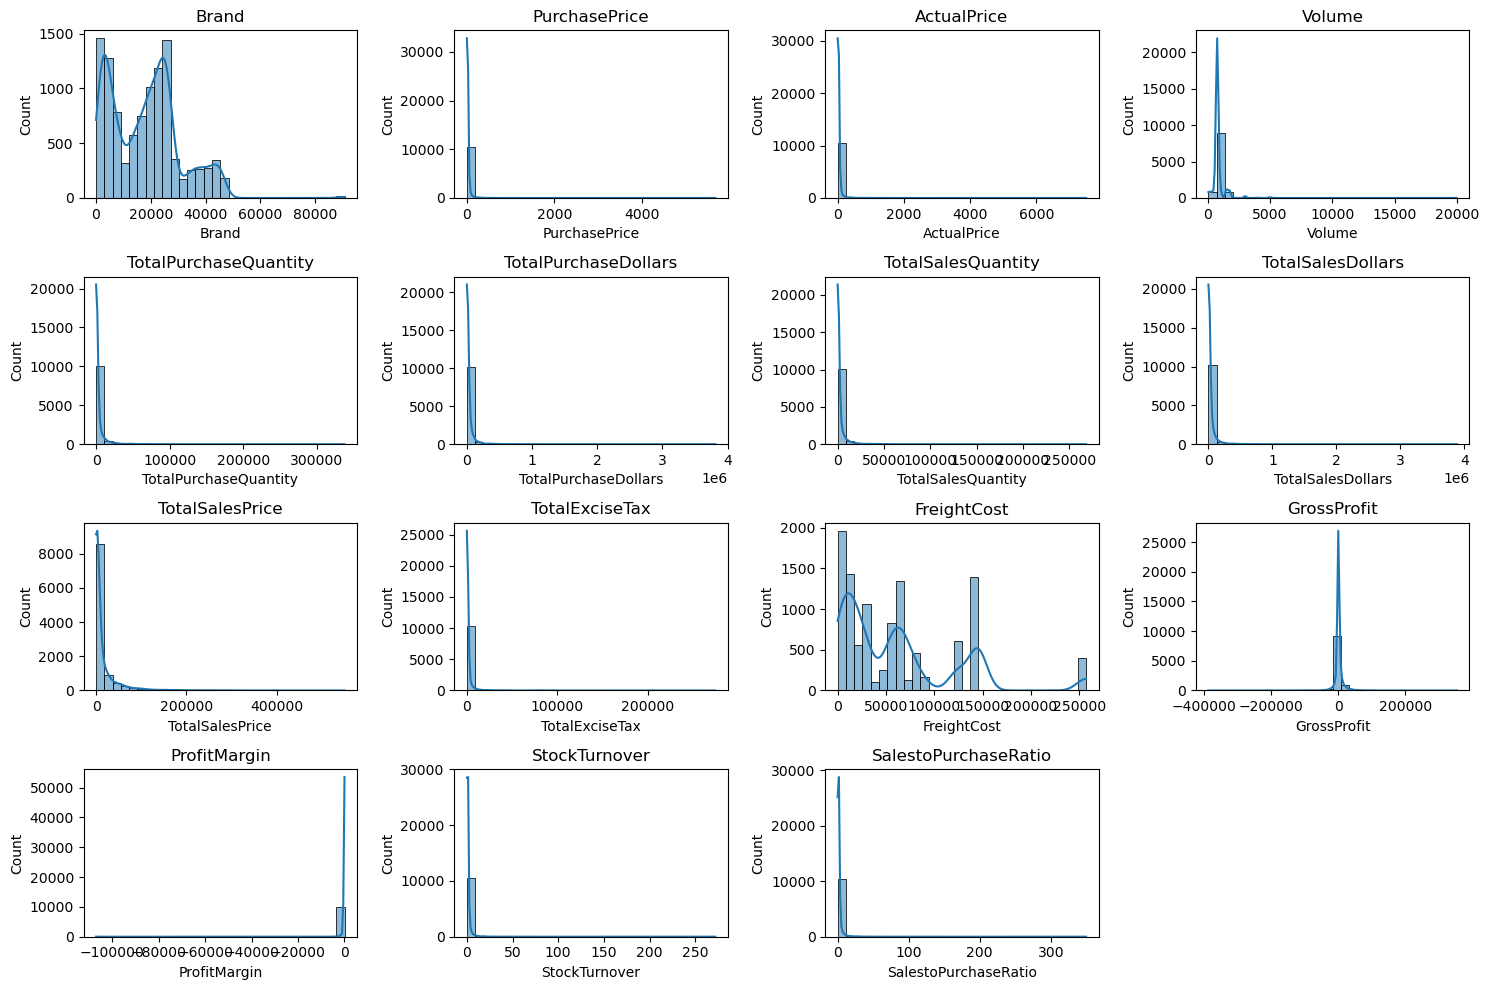

In [4]:
# Dstribution Plots for Numerical columns
# Distribution Plots for Numerical columns

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()
    

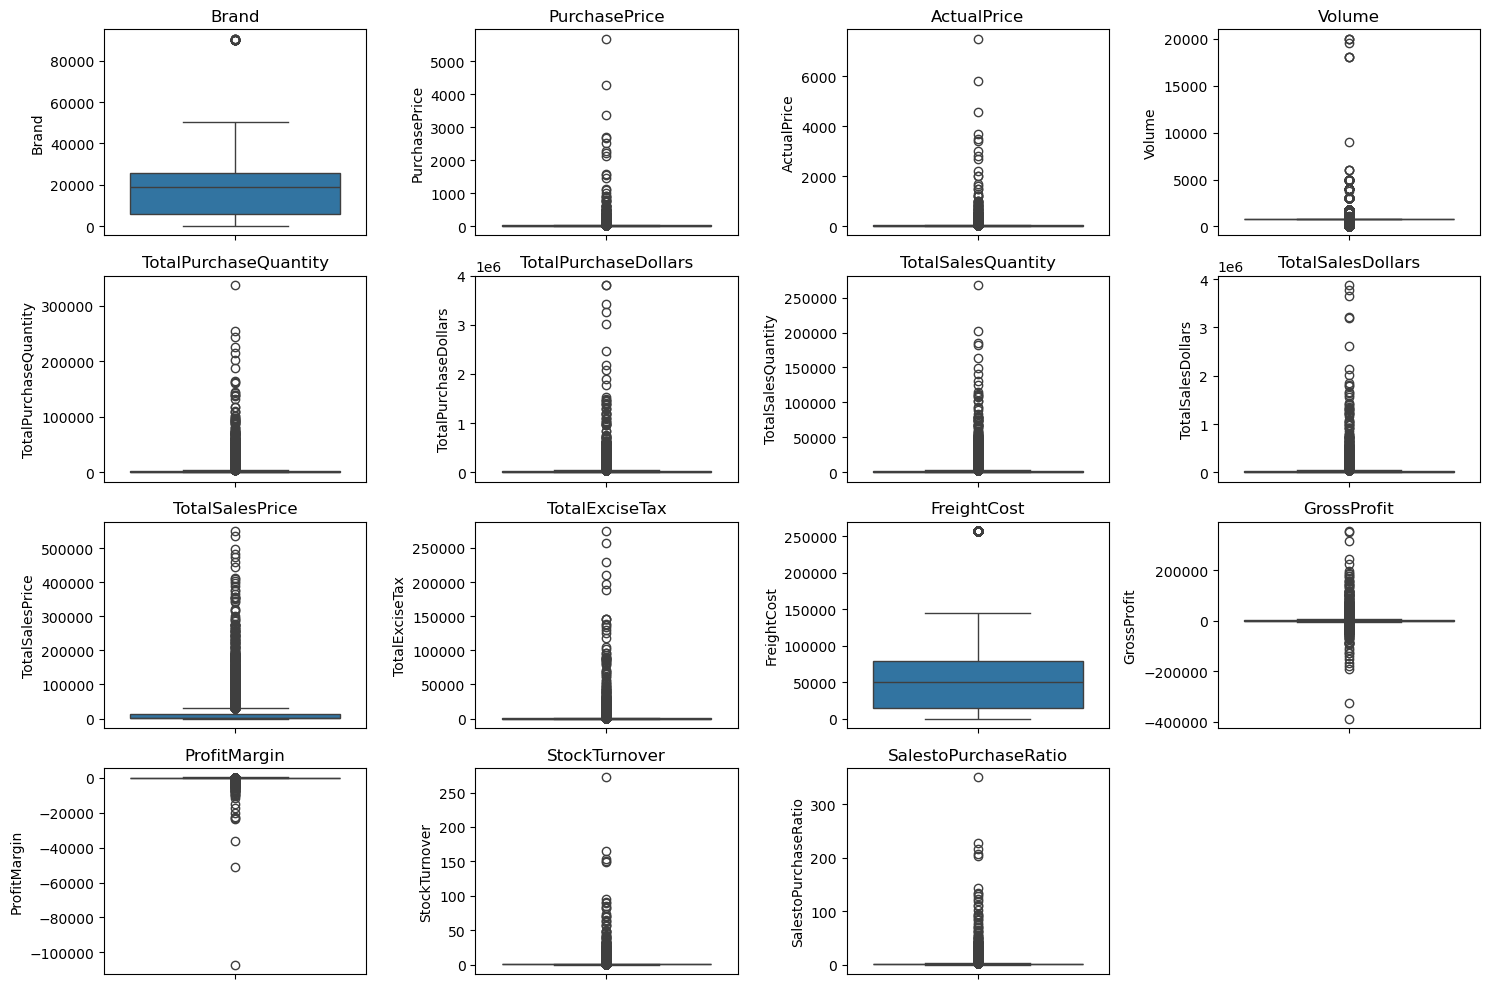

In [5]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()
    

In [6]:
df['TotalSalesQuantity'].min() and df['TotalSalesDollars'].min()

0.0

In [7]:
df['ProfitMargin'].min()

np.float64(-inf)

In [8]:
df['PurchasePrice'].max()

5681.81

In [9]:
 df["ActualPrice"].max()

7499.99

In [10]:
df["ActualPrice"].mean()

np.float64(35.64367096894875)

# Summary Statistics Insights:

## Negative & Zero Values:
 * Gross Profit: Minimum value is -386931.44, indicating losses. Some product or         transaction may be selling at a loss due to high costs or selling at Discounts
 lower than the purchase price...
 * Profit Margin: Has a minimums of -Infin, which suggest cases where revenu is zero o even lower than costs.
 * Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some product were purchasesd but never sold . These could be slow-moving or obsolete
 stock


## Outliers Indicated by High Standard Deviations
* Purchase & Actual Price: The max value(5,681.81 & 7,499.99) are singnificantly higher than the mean(24.38 & (35.64), indicating potential premium
  products.
* Freight Cost: Huge variation, from 0.09 to 257032.07, suggests logistics inefficiencies or bulk shipments.
* Stock Turnover: Range from 0 to 274.5, implying some product sell extremely fast while other remain in stock indefinitely.Value more than 1 indicates that
 Sold quantity for that product is higher than the purchased quantity  due to either sales are being fulfilled from older stock

In [11]:
# let's filter the data by removing inconsistences
df = pd.read_sql_query("""select * from vendor_sales_summary
where GrossProfit>0
AND ProfitMargin >0
AND TotalSalesQuantity>0""",conn)

In [12]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,107436.0,3881420.64,549794.09,197400.84,68601.68,70169.04,1.807818,0.740529,1.018411
1,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,149367.0,3643388.83,378570.51,274449.16,123780.22,225085.15,6.177906,0.797019,1.065847
2,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,102317.0,3209878.83,443700.00,187995.79,257032.07,186672.82,5.815572,0.740842,1.061747
3,480,BACARDI USA INC,3858,Grey Goose Vodka,17.77,23.99,750.0,138809,2466635.93,109366.0,2614606.34,364403.37,86113.40,89286.27,147970.41,5.659376,0.787888,1.059989
4,3960,DIAGEO NORTH AMERICA INC,3489,Tanqueray,20.73,27.99,1750.0,91835,1903739.55,73061.0,2148995.39,412567.30,134238.10,257032.07,245255.84,11.412581,0.795568,1.128828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6592,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2,2.84,14.0,27.86,5.97,0.73,257032.07,25.02,89.806174,7.000000,9.809859
6593,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
6594,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
6595,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,57.0,113.43,55.72,11.97,257032.07,111.96,98.704047,57.000000,77.163265


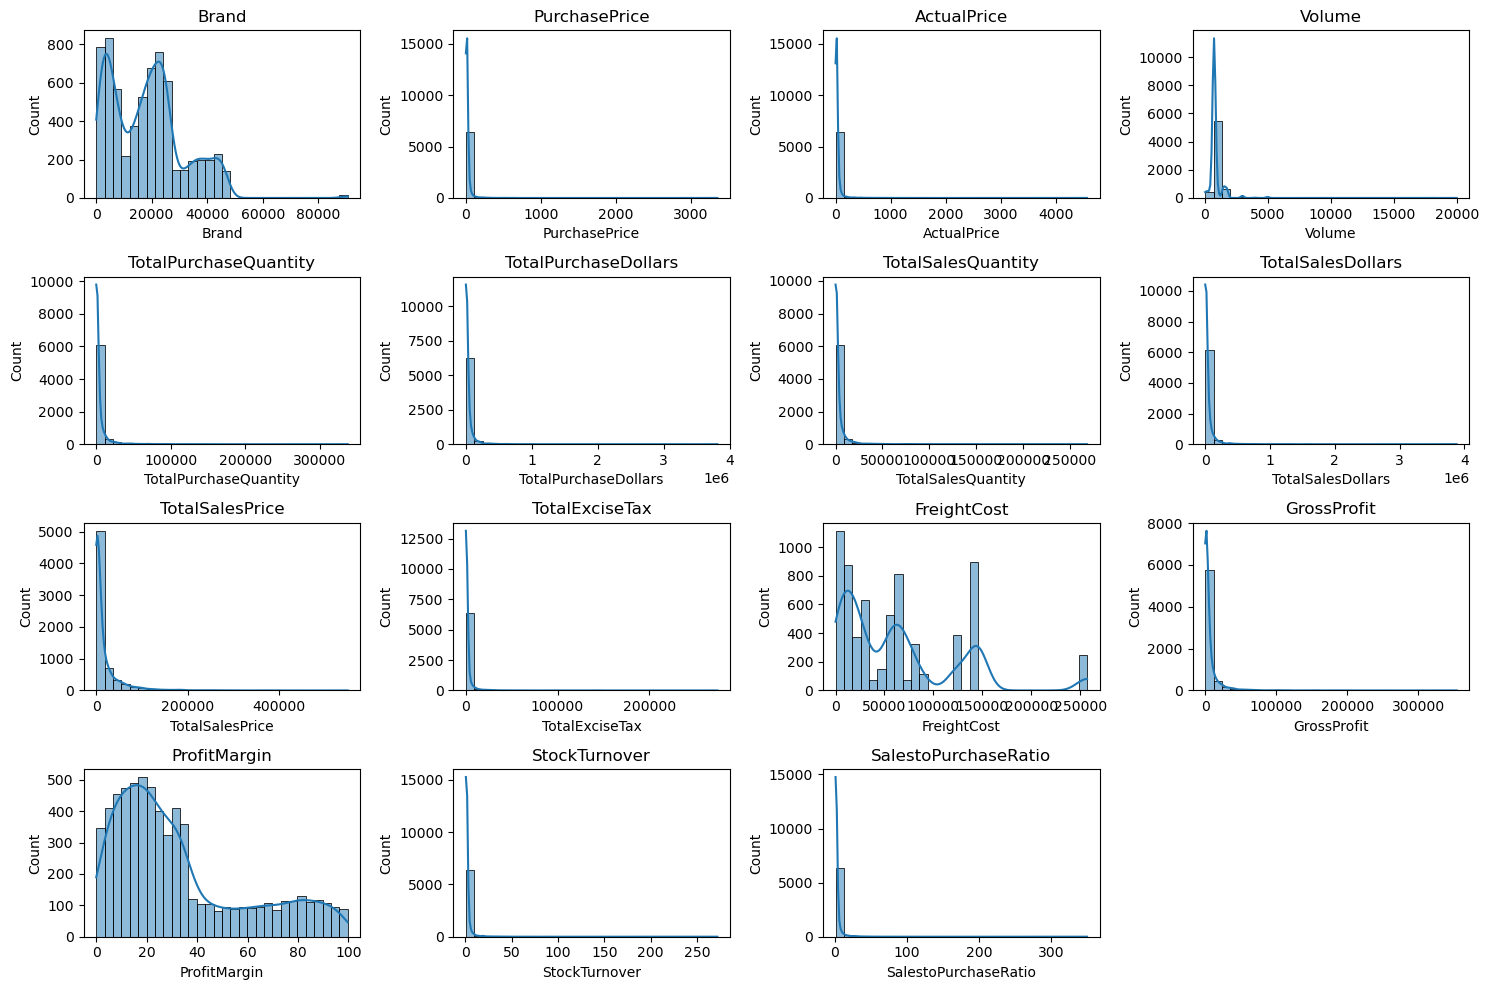

In [13]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()
    

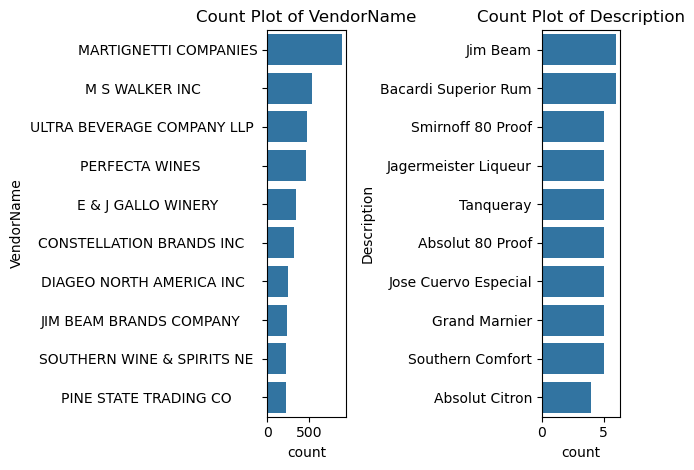

In [14]:
cat_cols=["VendorName","Description"]
for i, col in enumerate(cat_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()

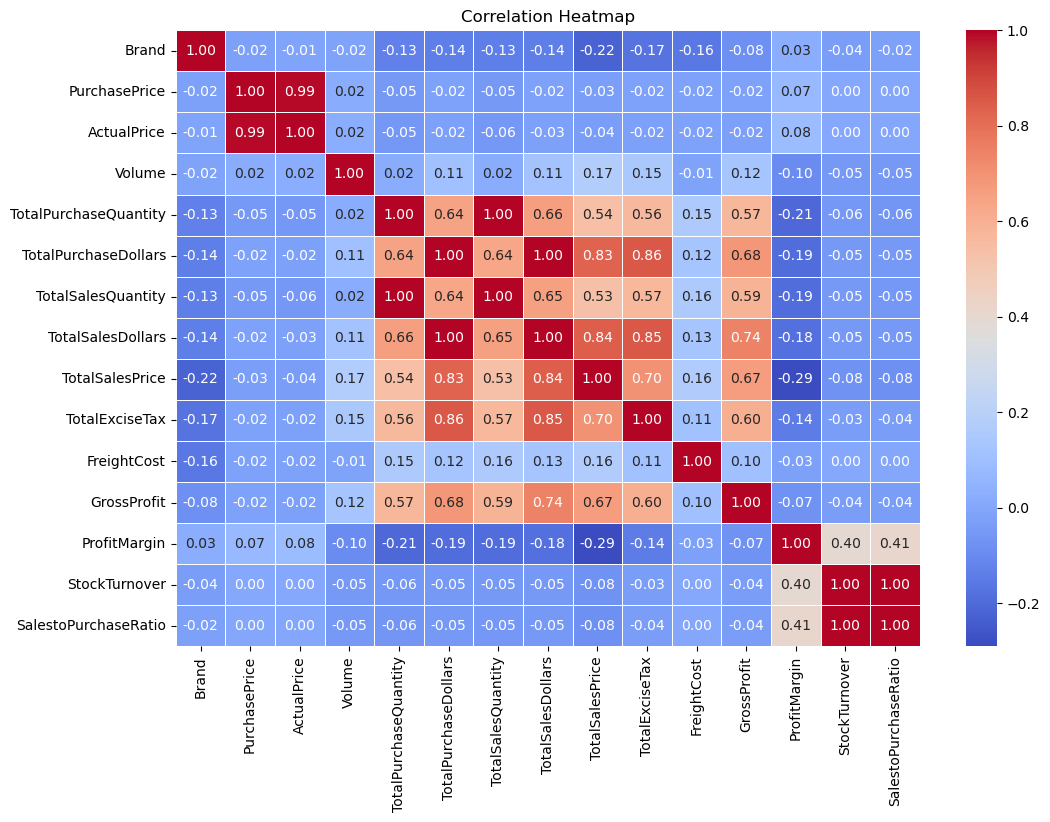

In [15]:
# correction Heatmap
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",          # corrected here
    cmap="coolwarm",    # lowercase is standard
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# Correlation Insights
* PurchasePrice shows weak correlation with TotalSalesDollars (-0.02) and GrossProfit    (-0.02), suggesting that price variations do not significantly impact sales revenue or profit.
* There is a moderate positive correlation between TotalPurchaseQuantity and TotalSalesQuantity (0.64), indicating that while purchasing and sales are related, they are not perfectly aligned. This suggests potential inefficiencies such as overstocking or unsold inventory, and highlights room for improvement in demand forecasting and inventory management.
* A negative correlation exists between ProfitMargin and TotalSalesPrice (-0.29), suggesting that as sales price increases, profit margins tend to decrease, possibly due to higher associated costs or competitive pricing strategies.
* StockTurnover shows a weak negative correlation with GrossProfit (-0.04) and a moderate positive correlation with ProfitMargin (0.40), indicating that while faster inventory turnover does not significantly impact overall profit, it may have some positive influence on profit margins.

# Data Analysis

Identify Brand that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher Profit margins

In [16]:
Brand_performance=df.groupby("Description").agg({
    "TotalSalesDollars": "sum","ProfitMargin": "mean"}).reset_index()

In [17]:
Brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,10 Span Cab Svgn CC,2306.92,7.332721
1,10 Span Chard CC,2951.06,18.644826
2,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
3,10 Span Pnt Nr CC,2089.71,13.342521
4,12 Days of Pearls Gift Set,309.69,97.678323
...,...,...,...
6047,Zorvino Bacca Z Blackberry,25951.45,10.157737
6048,Zorvino Fragole Z Strawberry,17753.31,5.482809
6049,Zorvino Vyds Pearz,14775.21,4.016593
6050,Zum Rsl,8719.29,16.166339


In [18]:
low_sales_threshold=Brand_performance["TotalSalesDollars"].quantile(0.15)
high_margin_threshold=Brand_performance["ProfitMargin"].quantile(0.85)

In [19]:
low_sales_threshold

np.float64(539.9064999999999)

In [20]:
high_margin_threshold

np.float64(69.70195796740806)

In [21]:
target_brands=Brand_performance[
(Brand_performance["TotalSalesDollars"]<=low_sales_threshold) &
(Brand_performance["ProfitMargin"] >=high_margin_threshold)
]
print("Brand with Low Sales but high profit Margins:")
display(target_brands.sort_values("TotalSalesDollars"))

Brand with Low Sales but high profit Margins:


,Description,TotalSalesDollars,ProfitMargin
1703,Concannon Glen Ellen Wh Zin,15.95,83.448276
1793,Crown Royal Apple,27.86,89.806174
4891,Sauza Sprklg Wild Berry Marg,27.96,82.153076
3792,Merry Irish Cream Liqueur,35.97,73.533500
5652,Tracia Syrah,44.94,88.495772
...,...,...,...
3047,Jadot Saint Aubin 13,531.86,90.147783
745,Bowman's Light Vodka,535.00,72.052336
2934,Il Poggione di Montalcino,536.97,78.212936
1055,Casa Liliana Good Chard,538.51,94.986166


In [22]:
Brand_performance = Brand_performance[Brand_performance["TotalSalesDollars"] < 10000]

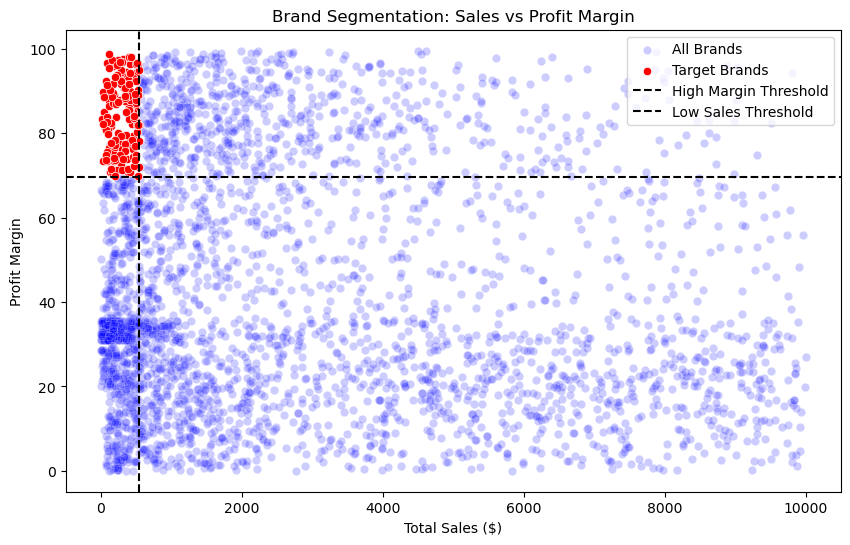

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=Brand_performance, 
                x='TotalSalesDollars', 
                y='ProfitMargin',
                color="blue", 
                label="All Brands", 
                alpha=0.2)

sns.scatterplot(data=target_brands, 
                x="TotalSalesDollars", 
                y="ProfitMargin", 
                color="red", 
                label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin")
plt.title("Brand Segmentation: Sales vs Profit Margin")

plt.legend()
plt.show()


 ### Which vendors and brands demonstrate  the highest sales performance?

In [24]:
top_vendors=df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands=df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC       30680985.48
MARTIGNETTI COMPANIES          23640399.80
JIM BEAM BRANDS COMPANY        18150928.73
CONSTELLATION BRANDS INC       17499218.91
BACARDI USA INC                17355273.13
PERNOD RICARD USA              13780472.49
E & J GALLO WINERY             12465913.35
BROWN-FORMAN CORP              11105835.32
M S WALKER INC                 10307542.77
ULTRA BEVERAGE COMPANY LLP     10145350.99
Name: TotalSalesDollars, dtype: float64

In [25]:
top_brands

Description
Jack Daniels No 7 Black    5634619.80
Grey Goose Vodka           5160213.31
Absolut 80 Proof           4962072.64
Ketel One Vodka            3509133.34
Tanqueray                  2793844.33
Jim Beam                   2576110.15
Jose Cuervo Especial       2133480.93
Bombay Sapphire Gin        2122054.20
Dewars White Label         1975623.51
Tito's Handmade Vodka      1952479.85
Name: TotalSalesDollars, dtype: float64

In [26]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return f"{value:.2f}"

In [27]:
top_brands.apply(lambda x: format_dollars(x))

Description
Jack Daniels No 7 Black    5.63M
Grey Goose Vodka           5.16M
Absolut 80 Proof           4.96M
Ketel One Vodka            3.51M
Tanqueray                  2.79M
Jim Beam                   2.58M
Jose Cuervo Especial       2.13M
Bombay Sapphire Gin        2.12M
Dewars White Label         1.98M
Tito's Handmade Vodka      1.95M
Name: TotalSalesDollars, dtype: object

In [28]:
top_vendors.apply(lambda x: format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC       30.68M
MARTIGNETTI COMPANIES          23.64M
JIM BEAM BRANDS COMPANY        18.15M
CONSTELLATION BRANDS INC       17.50M
BACARDI USA INC                17.36M
PERNOD RICARD USA              13.78M
E & J GALLO WINERY             12.47M
BROWN-FORMAN CORP              11.11M
M S WALKER INC                 10.31M
ULTRA BEVERAGE COMPANY LLP     10.15M
Name: TotalSalesDollars, dtype: object

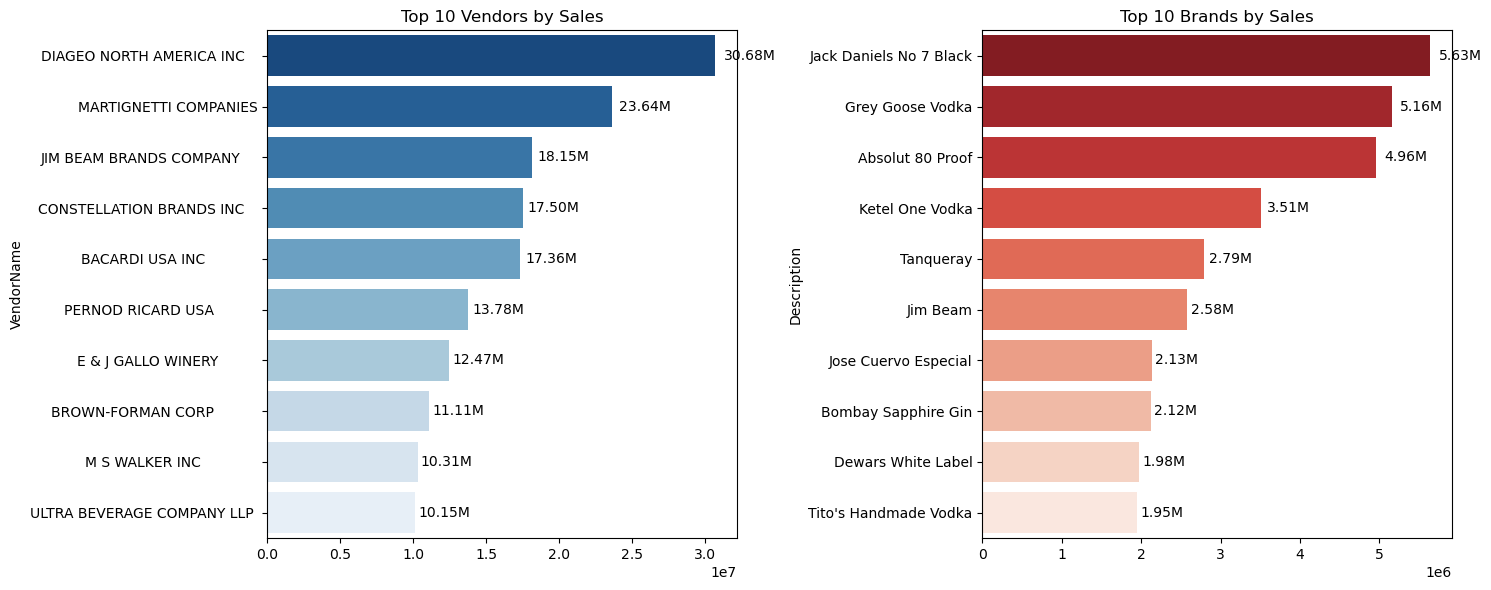

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# 🔹 Plot 1: Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center', fontsize=10, color='black'
    )

# 🔹 Plot 2: Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center', fontsize=10, color='black'
    )

plt.tight_layout()
plt.show()

### Which vendors contribute the most to total purchase dollars?

In [30]:
vendor_performance=df.groupby('VendorName').agg({
    "TotalPurchaseDollars":"sum",
    "GrossProfit": "sum",
    "TotalSalesDollars":"sum"}).reset_index()
vendor_performance


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ALISA CARR BEVERAGES,25698.12,64042.33,89740.45
1,ALTAMAR BRANDS LLC,11427.20,820.35,12247.55
2,AMERICAN SPIRITS EXCHANGE,934.08,307.23,1241.31
3,AMERICAN VINTAGE BEVERAGE,104435.68,6356.03,110791.71
4,ATLANTIC IMPORTING COMPANY,3230.68,8617.24,11847.92
...,...,...,...,...
105,WEIN BAUER INC,605.52,191.76,797.28
106,WESTERN SPIRITS BEVERAGE CO,119933.83,32840.65,152774.48
107,WILLIAM GRANT & SONS INC,2363406.14,221223.39,2584629.53
108,WINE GROUP INC,5061166.76,1423138.44,6484305.20


In [31]:
vendor_performance["PurchaseContribution%"]=vendor_performance["TotalPurchaseDollars"]/vendor_performance["TotalPurchaseDollars"].sum()*100

In [32]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,ALISA CARR BEVERAGES,25698.12,64042.33,89740.45,0.011907
1,ALTAMAR BRANDS LLC,11427.20,820.35,12247.55,0.005295
2,AMERICAN SPIRITS EXCHANGE,934.08,307.23,1241.31,0.000433
3,AMERICAN VINTAGE BEVERAGE,104435.68,6356.03,110791.71,0.048390
4,ATLANTIC IMPORTING COMPANY,3230.68,8617.24,11847.92,0.001497
...,...,...,...,...,...
105,WEIN BAUER INC,605.52,191.76,797.28,0.000281
106,WESTERN SPIRITS BEVERAGE CO,119933.83,32840.65,152774.48,0.055571
107,WILLIAM GRANT & SONS INC,2363406.14,221223.39,2584629.53,1.095073
108,WINE GROUP INC,5061166.76,1423138.44,6484305.20,2.345068


In [33]:
vendor_performance=round(vendor_performance.sort_values("PurchaseContribution%", ascending=False),2)

In [34]:
# display Top 10 Vendors
top_vendors=vendor_performance.head(10)
top_vendors["TotalSalesDollars"]=top_vendors["TotalSalesDollars"].apply(format_dollars) 
top_vendors["TotalPurchaseDollars"]=top_vendors["TotalPurchaseDollars"].apply(format_dollars)
top_vendors["GrossProfit"]=top_vendors["GrossProfit"].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
24,DIAGEO NORTH AMERICA INC,27.46M,3.23M,30.68M,12.72
52,MARTIGNETTI COMPANIES,18.50M,5.14M,23.64M,8.57
42,JIM BEAM BRANDS COMPANY,16.37M,1.78M,18.15M,7.58
5,BACARDI USA INC,15.28M,2.07M,17.36M,7.08
19,CONSTELLATION BRANDS INC,13.65M,3.85M,17.50M,6.33
64,PERNOD RICARD USA,12.48M,1.30M,13.78M,5.78
28,E & J GALLO WINERY,10.18M,2.29M,12.47M,4.72
10,BROWN-FORMAN CORP,10.10M,1.01M,11.11M,4.68
49,M S WALKER INC,8.42M,1.89M,10.31M,3.90
99,ULTRA BEVERAGE COMPANY LLP,7.95M,2.19M,10.15M,3.68


In [35]:
top_vendors["PurchaseContribution%"].sum()

np.float64(65.04)

In [36]:
top_vendors["Cumulative_Contribution%"]=top_vendors["PurchaseContribution%"].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
24,DIAGEO NORTH AMERICA INC,27.46M,3.23M,30.68M,12.72,12.72
52,MARTIGNETTI COMPANIES,18.50M,5.14M,23.64M,8.57,21.29
42,JIM BEAM BRANDS COMPANY,16.37M,1.78M,18.15M,7.58,28.87
5,BACARDI USA INC,15.28M,2.07M,17.36M,7.08,35.95
19,CONSTELLATION BRANDS INC,13.65M,3.85M,17.50M,6.33,42.28
64,PERNOD RICARD USA,12.48M,1.30M,13.78M,5.78,48.06
28,E & J GALLO WINERY,10.18M,2.29M,12.47M,4.72,52.78
10,BROWN-FORMAN CORP,10.10M,1.01M,11.11M,4.68,57.46
49,M S WALKER INC,8.42M,1.89M,10.31M,3.90,61.36
99,ULTRA BEVERAGE COMPANY LLP,7.95M,2.19M,10.15M,3.68,65.04


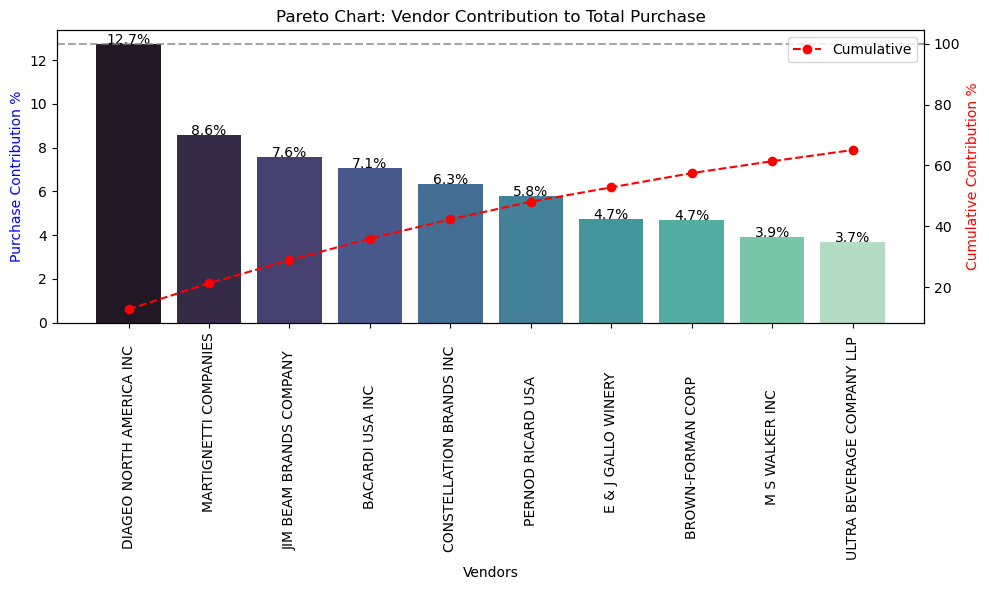

In [37]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot (Purchase Contribution %)
sns.barplot(
    x=top_vendors["VendorName"], 
    y=top_vendors["PurchaseContribution%"], 
    palette="mako", 
    ax=ax1
)

# Add labels on bars
for i, value in enumerate(top_vendors["PurchaseContribution%"]):
    ax1.text(i, value, f"{value:.1f}%", ha='center', fontsize=10, color='black')

# Line plot (Cumulative Contribution %)
ax2 = ax1.twinx()
ax2.plot(
    top_vendors["VendorName"], 
    top_vendors["Cumulative_Contribution%"], 
    color="red", 
    marker="o", 
    linestyle="dashed", 
    label="Cumulative"
)

# Labels and formatting
ax1.set_xticklabels(top_vendors["VendorName"], rotation=90)
ax1.set_ylabel("Purchase Contribution %", color="blue")
ax2.set_ylabel("Cumulative Contribution %", color="red")
ax1.set_xlabel("Vendors")
ax1.set_title("Pareto Chart: Vendor Contribution to Total Purchase")

# 100% reference line
ax2.axhline(y=100, color="gray", linestyle="dashed", alpha=0.7)

ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()     


#### how much of total procurment is dependent on the top vendors?

In [38]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%")

Total Purchase Contribution of top 10 vendors is 65.04%


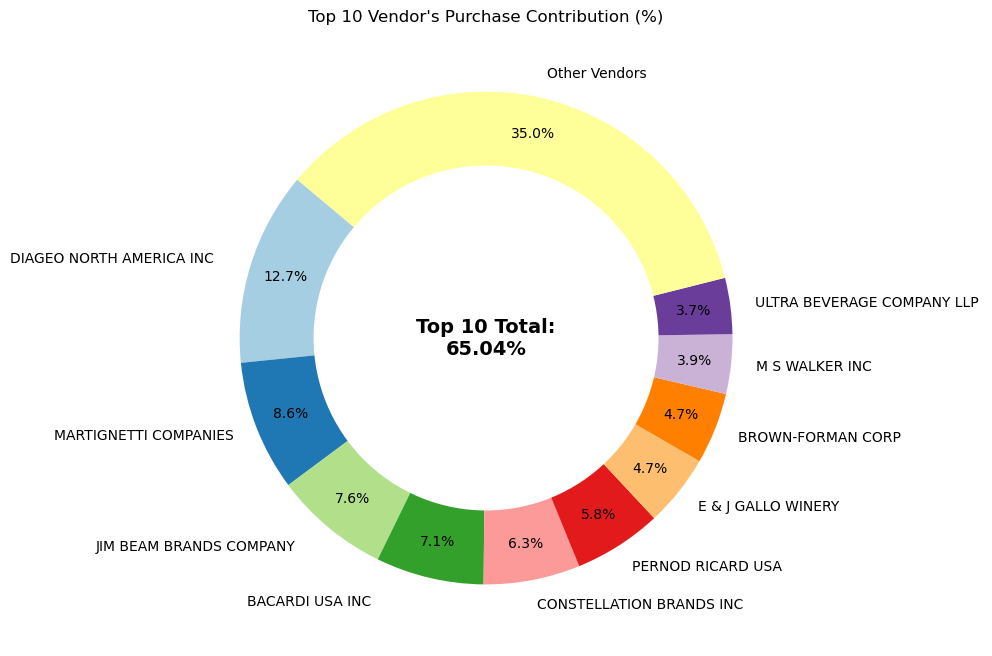

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))

vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors"
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)
# Draw white circle (donut effect)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

# Center text
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

##### Dose purchasing in builk reduce the unit price , and what is the optimal purcahse volume for cost sacvings?

In [40]:
df["UnitPurchasePrice"]=df["TotalPurchaseDollars"] / df["TotalPurchaseQuantity"]

In [41]:
df["OrderSize"]=pd.qcut(df["TotalPurchaseQuantity"],q=3, labels=["Small","Medium","Large"])

In [42]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice,OrderSize
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,107436.0,3881420.64,549794.09,197400.84,68601.68,70169.04,1.807818,0.740529,1.018411,26.27,Large
1,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,149367.0,3643388.83,378570.51,274449.16,123780.22,225085.15,6.177906,0.797019,1.065847,18.24,Large
2,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,102317.0,3209878.83,443700.00,187995.79,257032.07,186672.82,5.815572,0.740842,1.061747,21.89,Large
3,480,BACARDI USA INC,3858,Grey Goose Vodka,17.77,23.99,750.0,138809,2466635.93,109366.0,2614606.34,364403.37,86113.40,89286.27,147970.41,5.659376,0.787888,1.059989,17.77,Large
4,3960,DIAGEO NORTH AMERICA INC,3489,Tanqueray,20.73,27.99,1750.0,91835,1903739.55,73061.0,2148995.39,412567.30,134238.10,257032.07,245255.84,11.412581,0.795568,1.128828,20.73,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6592,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2,2.84,14.0,27.86,5.97,0.73,257032.07,25.02,89.806174,7.000000,9.809859,1.42,Small
6593,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32,Small
6594,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39,Small
6595,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,57.0,113.43,55.72,11.97,257032.07,111.96,98.704047,57.000000,77.163265,1.47,Small


In [43]:
df.groupby("OrderSize")[["UnitPurchasePrice"]].mean()

,UnitPurchasePrice
OrderSize,
Small,42.280746
Medium,13.474320
Large,9.458486


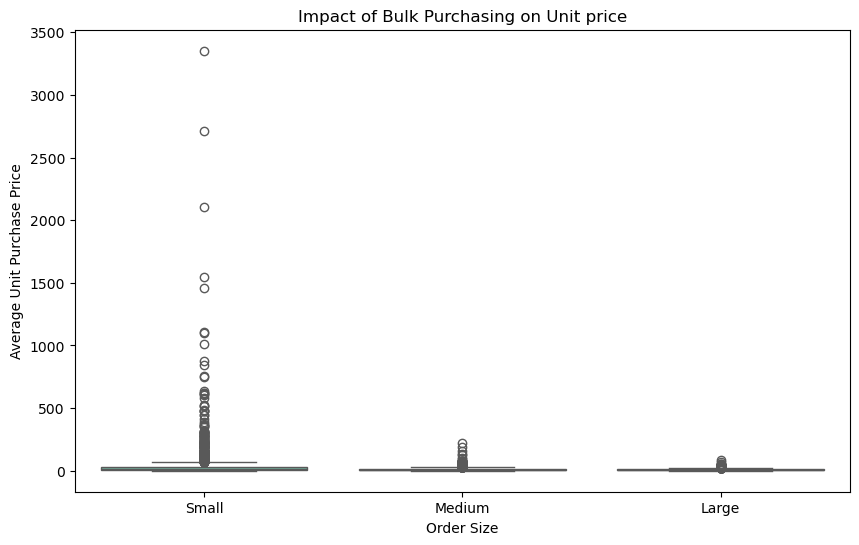

In [44]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="OrderSize",y="UnitPurchasePrice",palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

* Vendor Buying in bulk (Large size) get the lowest unit price($ 9.45 per unit ), meaning if they can manage inventory effciently
* The price difference between small and large order is substantia(-72 % reduction  in unit cost)
* This suggests that bulk pricing strategies successfully  encourage vendore to purchase in larger volume, leading to higher overll sales despite lower per -unit revenue.

#### Which vendores have low inventory turnover, indicating excess stock and slow - moving product

In [45]:
df[df["StockTurnover"]<1].groupby("VendorName")[["StockTurnover"]].mean().sort_values("StockTurnover",ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.500000
Dunn Wine Brokers,0.679293
LABELLE VYDS AND WINERY,0.679367
CANDIA VINEYARDS,0.688425
JEWELL TOWNE VINEYARDS,0.688533
INCREDIBREW INC,0.694158
SWEET BABY VINEYARD,0.694899
MOONLIGHT MEADERY,0.700000
STELLAR IMPORTING CO LLC,0.705020


#### How much capital is locketed in unsold inventory per vendore and which vendore contribution the most to it

In [46]:
df["UnsoldInventoryValue"]=(df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) #* df["PurchasePrice"]

print('Total Unsold Capital :', format_dollars(df["UnsoldInventoryValue"].sum()))
                                               
                            

Total Unsold Capital : 5.03M


In [47]:
print(format_dollars(df["TotalSalesQuantity"].sum()))

20.45M


In [48]:
# Aggregate CApital Locked per Vendore
inventory_value_per_vendor=df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()
# Sort Vendore With the Highest Locked Capital
inventory_value_per_vendor=inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor["UnsoldInventoryValue"]=inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)
inventory_value_per_vendor.head(10)


,VendorName,UnsoldInventoryValue
24,DIAGEO NORTH AMERICA INC,736.52K
19,CONSTELLATION BRANDS INC,444.51K
52,MARTIGNETTI COMPANIES,411.61K
42,JIM BEAM BRANDS COMPANY,393.01K
28,E & J GALLO WINERY,371.86K
49,M S WALKER INC,231.00K
75,SAZERAC CO INC,226.66K
64,PERNOD RICARD USA,202.40K
108,WINE GROUP INC,190.03K
5,BACARDI USA INC,189.13K


####  What is the 95% confidence intervals for profit margine for top performing and low performimg vendors

In [49]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df["TotalSalesDollars"].quantile(0.25)

In [50]:
top_vendors=df[df["TotalSalesDollars"]>=top_threshold]["ProfitMargin"].dropna()
low_vendors=df[df["TotalSalesDollars"] <=low_threshold]["ProfitMargin"].dropna()

In [51]:
low_vendors

4262     0.030697
4302     6.535337
4309     3.967281
4320     6.312292
4323     7.707659
          ...    
6592    89.806174
6593    83.448276
6594    96.436186
6595    98.704047
6596    99.166079
Name: ProfitMargin, Length: 1650, dtype: float64

In [55]:
def confidence_interval(data, confidence=0.95):
    mean_val=np.mean(data)
    std_err=np.std(data, ddof=1)/  np.sqrt(len(data)) # standard
    t_critical=stats.t.ppf((1+confidence) /2, df=len(data)-1)
    margin_of_error=t_critical*std_err
    return mean_val,mean_val-margin_of_error, mean_val+margin_of_error

Top Vendors 95% CI: (16.80, 18.06), Mean:  17.43
Low Vendors 95% CI: (42.54, 45.17), Mean:  17.43


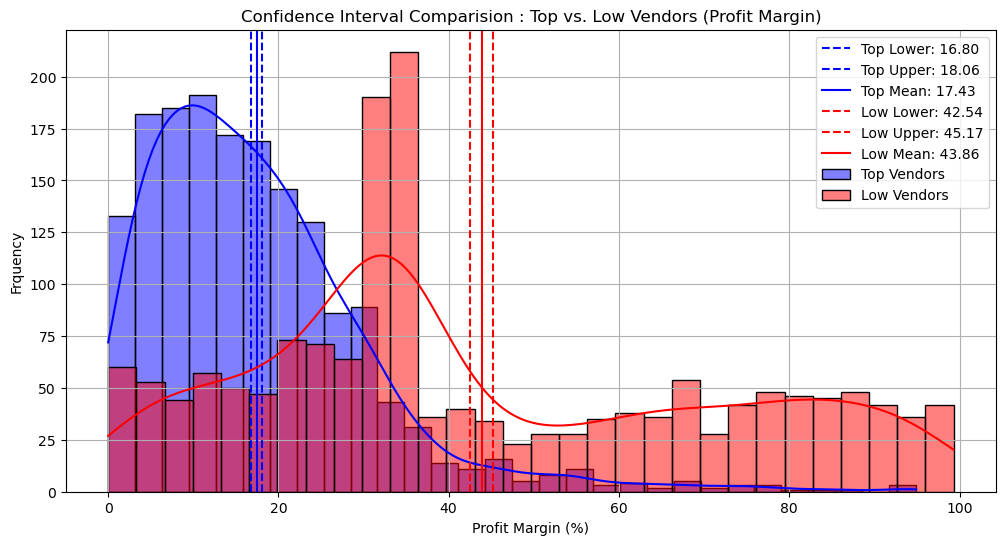

In [65]:
top_mean,top_lower,top_upper=confidence_interval(top_vendors)
low_mean, low_lower,low_upper= confidence_interval(low_vendors)
print(f"Top Vendors 95% CI: ({ top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean: .2f}")
print(f"Low Vendors 95% CI: ({ low_lower:.2f}, {low_upper:.2f}), Mean: {top_mean: .2f}")

plt.figure(figsize=(12,6))
# Top Vendor Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean,  color="blue", linestyle="-",  label=f"Top Mean: {top_mean:.2f}") 

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="r", bins=30, alpha=0.5, label="Low Vendors")

plt.axvline(low_lower, color="r", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="r", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean,  color="r", linestyle="-",  label=f"Low Mean: {low_mean:.2f}")

plt.legend() 


# FInalize Plot

plt.title("Confidence Interval Comparision : Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frquency")
plt.legend()
plt.grid(True)
plt.show()           
           



* * Two groups enter the market
* There are Top Vendors (blue) and Low Vendors (red). Everyone assumes the top ones make more profit.

* The top vendors play a volume game

* They keep prices lower, so their profit margins stay around 17%, but they likely sell a lot more.

* The low vendors take a different path

* They charge higher prices, so their margins are around 43%, but they don’t sell as much.

* The gap is clear and real

* The lines (confidence intervals) don’t overlap at all—this isn’t random. The difference is statistically strong.

* The twist (the real lesson)

* Being a “top vendor” doesn’t mean higher margin—it likely means better sales performance, not pricing power.

* Top vendors win by selling more at lower margins, while low vendors earn more per sale but sell less.



### Is there a singnificant diffence in profit margine between top-performing and low- performing vendors?
Hypothesis:

H not(Null Hypothesis): There is not significants difference in the mean profit margine of top-performing and low-performomg vendors.

H ONE(Alternate Hypothesis):The mean profit margins of top -performannce and low -performing vendors are significantly different

In [69]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df["TotalSalesDollars"].quantile(0.25)

top_vendors=df[df["TotalSalesDollars"]>=top_threshold]["ProfitMargin"].dropna()
low_vendors=df[df["TotalSalesDollars"] <=low_threshold]["ProfitMargin"].dropna()

# Perform Two -Sample T- Test
t_stat,p_value=ttest_ind(top_vendors,low_vendors, equal_var=False)

# print results

print(f"T-Statistic: {t_stat:.4f}, p_value:{p_value:.4f}")
if p_value <0.05:
    print("Reject H not: There is a singificant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H not : No significant difference in profit margins.")

T-Statistic: -35.5580, p_value:0.0000
Reject H not: There is a singificant difference in profit margins between top and low-performing vendors.
